Notebook 2 - Veri Görselleştirme

Bu notebook'ta veri keşfi sonucunda elde edilen bulgular grafiklerle görselleştirilmiştir.

Bu kapsamda:
- İlçelere göre kayıt sayıları karşılaştırılmıştır.
- Hesap sınıflarının dağılımı incelenmiştir.
- Aylık ortalama elektrik tüketimi görselleştirilmiştir.
- Elektrik tüketim dağılımı analiz edilmiştir.
- Tahsilat verileri farklı ödeme yöntemlerine göre görselleştirilmiştir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
file_path = "/content/elektrik_veri_hashed.xlsx"

df_hamamozu = pd.read_excel(file_path, sheet_name="Tahakkuk")
df_gumushacikoy = pd.read_excel(file_path, sheet_name="Tahakkuk 1")
df_goynucek = pd.read_excel(file_path, sheet_name="Tahakkuk 2")

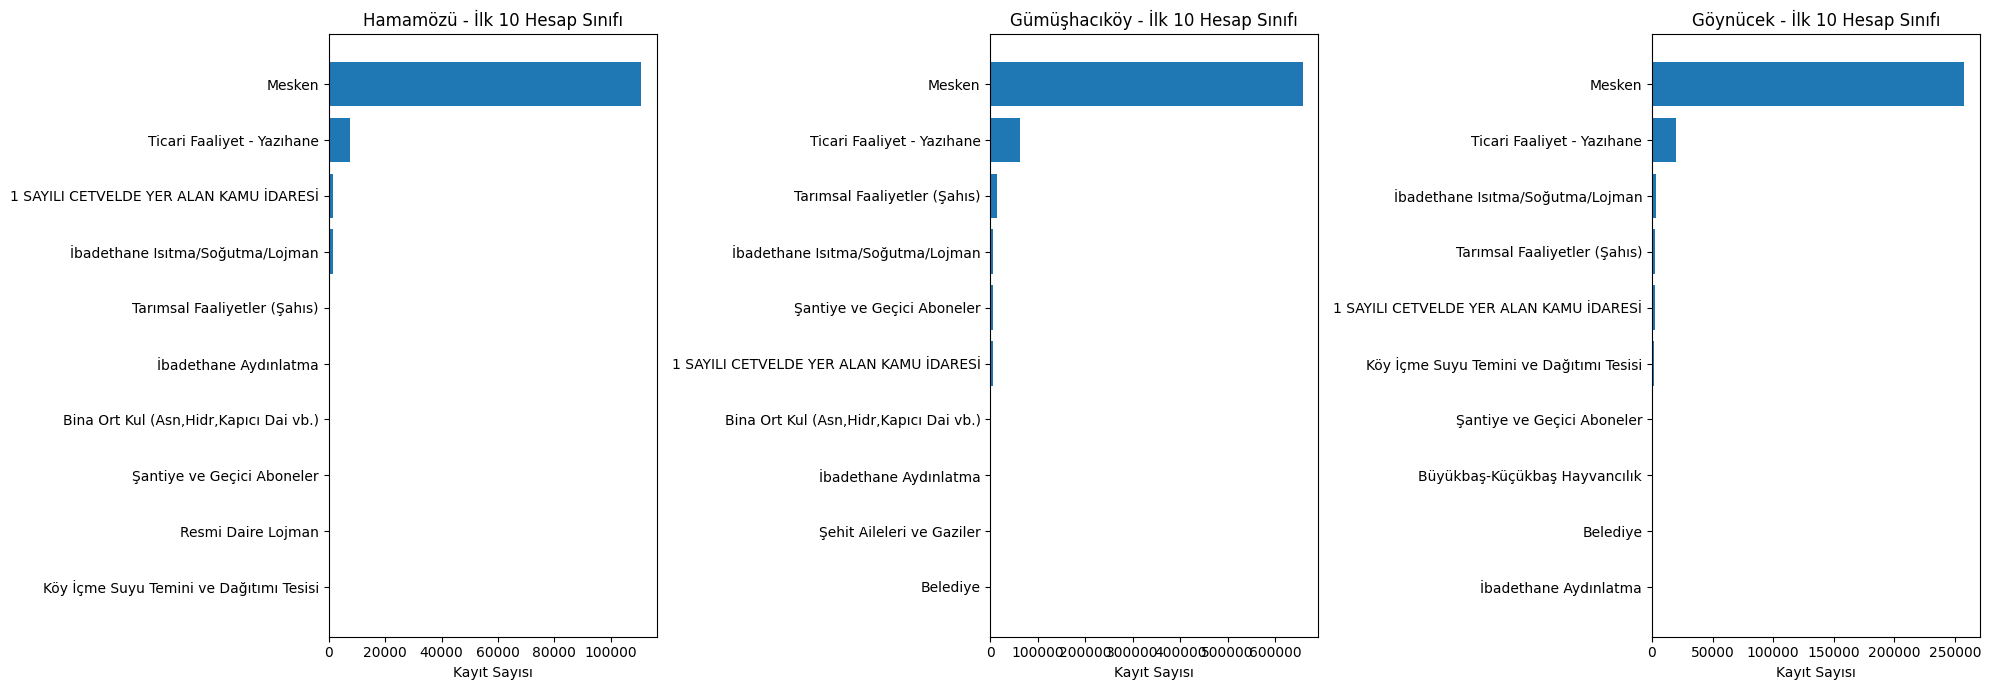

In [6]:
ham_top10 = df_hamamozu["Hesap Sınıfı"].value_counts().head(10)
gum_top10 = df_gumushacikoy["Hesap Sınıfı"].value_counts().head(10)
goy_top10 = df_goynucek["Hesap Sınıfı"].value_counts().head(10)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].barh(ham_top10.index, ham_top10.values)
axes[0].set_title("Hamamözü - İlk 10 Hesap Sınıfı")
axes[0].set_xlabel("Kayıt Sayısı")
axes[0].invert_yaxis()

axes[1].barh(gum_top10.index, gum_top10.values)
axes[1].set_title("Gümüşhacıköy - İlk 10 Hesap Sınıfı")
axes[1].set_xlabel("Kayıt Sayısı")
axes[1].invert_yaxis()

axes[2].barh(goy_top10.index, goy_top10.values)
axes[2].set_title("Göynücek - İlk 10 Hesap Sınıfı")
axes[2].set_xlabel("Kayıt Sayısı")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

Üç ilçede de en yaygın hesap sınıfı Mesken aboneleridir. Bununla birlikte kayıt sayıları ve diğer hesap sınıflarının ağırlıkları ilçelere göre değişmektedir. Gümüşhacıköy, toplam müşteri ve kayıt sayısı bakımından diğer ilçelerden belirgin biçimde büyüktür.

In [8]:
for df in [df_hamamozu, df_gumushacikoy, df_goynucek]:
    df["mali_yil_donem"] = pd.to_datetime(
        df["mali_yil_donem"],
        errors="coerce"
    )
    df["ay"] = df["mali_yil_donem"].dt.month

In [9]:
ham_aylik = df_hamamozu.groupby("ay")["kwh"].mean()
gum_aylik = df_gumushacikoy.groupby("ay")["kwh"].mean()
goy_aylik = df_goynucek.groupby("ay")["kwh"].mean()

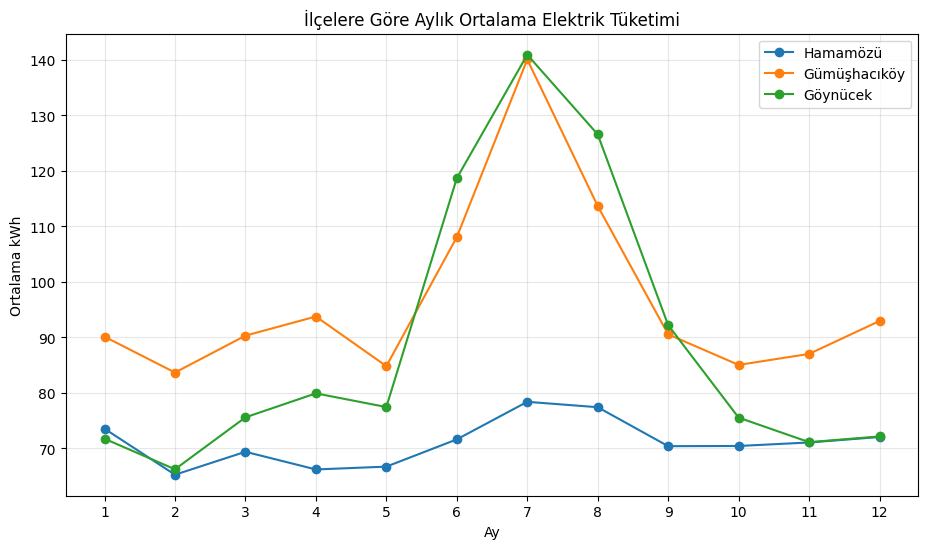

In [10]:
plt.figure(figsize=(11, 6))

plt.plot(ham_aylik.index, ham_aylik.values, marker="o", label="Hamamözü")
plt.plot(gum_aylik.index, gum_aylik.values, marker="o", label="Gümüşhacıköy")
plt.plot(goy_aylik.index, goy_aylik.values, marker="o", label="Göynücek")

plt.title("İlçelere Göre Aylık Ortalama Elektrik Tüketimi")
plt.xlabel("Ay")
plt.ylabel("Ortalama kWh")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [15]:
df_tahakkuk = pd.concat(
    [
        df_hamamozu,
        df_gumushacikoy,
        df_goynucek
    ],
    ignore_index=True
)

print(df_tahakkuk.shape)

(1185698, 11)


Grafikte kullanılan alt sınır: 0.0
Grafikte kullanılan üst sınır: 509.02
Grafikte kullanılan kayıt sayısı: 1173690


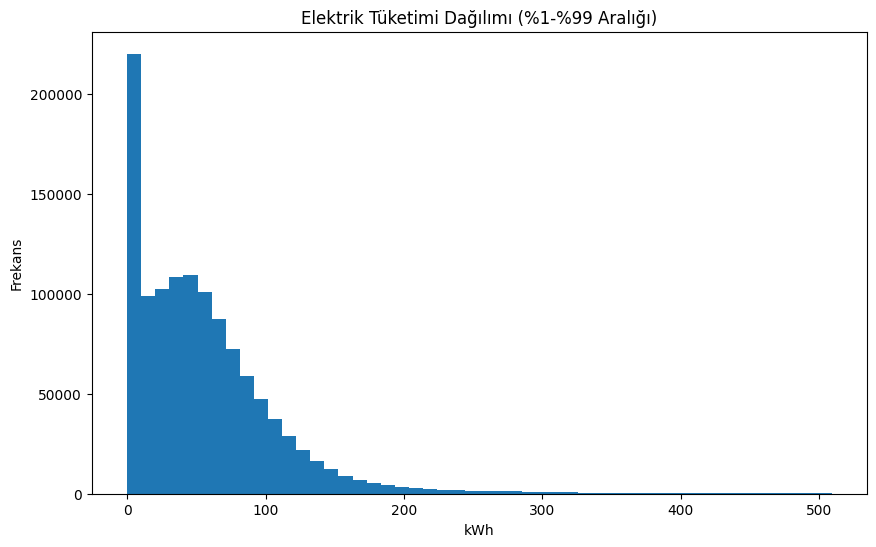

In [17]:
alt_sinir = df_tahakkuk["kwh"].quantile(0.01)
ust_sinir = df_tahakkuk["kwh"].quantile(0.99)

kwh_filtreli = df_tahakkuk[
    (df_tahakkuk["kwh"] >= alt_sinir) &
    (df_tahakkuk["kwh"] <= ust_sinir)
]["kwh"]

print("Grafikte kullanılan alt sınır:", round(alt_sinir, 2))
print("Grafikte kullanılan üst sınır:", round(ust_sinir, 2))
print("Grafikte kullanılan kayıt sayısı:", len(kwh_filtreli))

plt.figure(figsize=(10, 6))
plt.hist(kwh_filtreli, bins=50)

plt.title("Elektrik Tüketimi Dağılımı (%1-%99 Aralığı)")
plt.xlabel("kWh")
plt.ylabel("Frekans")

plt.show()

Ham kWh dağılımı, çok yüksek ve negatif uç değerler nedeniyle sıkışık görünmektedir. Bu nedenle ana tüketim davranışını daha net gösterebilmek için %1 ile %99 arasındaki değerler görselleştirilmiştir. Tüketimlerin büyük bölümünün düşük seviyelerde yoğunlaştığı görülmektedir.

In [18]:
print("Minimum kWh:", df_tahakkuk["kwh"].min())
print("Maksimum kWh:", df_tahakkuk["kwh"].max())
print("Negatif kayıt sayısı:", (df_tahakkuk["kwh"] < 0).sum())
print(
    "%99 sınırının üzerindeki kayıt sayısı:",
    (df_tahakkuk["kwh"] > ust_sinir).sum()
)

Minimum kWh: -25370.64
Maksimum kWh: 153575.73
Negatif kayıt sayısı: 151
%99 sınırının üzerindeki kayıt sayısı: 11857


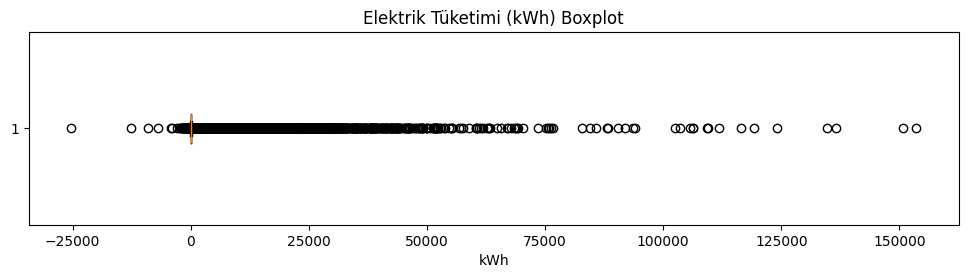

In [20]:
plt.figure(figsize=(12, 2.5))

plt.boxplot(
    df_tahakkuk["kwh"],
    vert=False,
    showfliers=True
)

plt.title("Elektrik Tüketimi (kWh) Boxplot")
plt.xlabel("kWh")

plt.show()

In [21]:
Q1 = df_tahakkuk["kwh"].quantile(0.25)
Q3 = df_tahakkuk["kwh"].quantile(0.75)

IQR = Q3 - Q1

alt = Q1 - 1.5 * IQR
ust = Q3 + 1.5 * IQR

aykiri = df_tahakkuk[
    (df_tahakkuk["kwh"] < alt) |
    (df_tahakkuk["kwh"] > ust)
]

print("Alt sınır :", round(alt, 2))
print("Üst sınır :", round(ust, 2))
print("Aykırı kayıt sayısı :", len(aykiri))

Alt sınır : -74.97
Üst sınır : 172.98
Aykırı kayıt sayısı : 48554


In [22]:
df_tahsilat = pd.read_excel(
    file_path,
    sheet_name="Tahsilat"
)

df_tahsilat.shape

(636993, 9)

In [23]:
print(df_tahsilat.columns.tolist())

['Şube', 'Kasa', 'İlçe', 'Söz.hsp.(bağımsız)', 'Tahsilat Tarihi', 'Nakit Tahsilat', 'Mahsuben Tahsilat', 'Kredi Kartı Tahsilatı', 'Banka Tahsilatı']


In [26]:
df_tahsilat.head()

,Şube,Kasa,İlçe,Söz.hsp.(bağımsız),Tahsilat Tarihi,Nakit Tahsilat,Mahsuben Tahsilat,Kredi Kartı Tahsilatı,Banka Tahsilatı
0,Tayin edilmedi,Tayin edilmedi,TAŞOVA,4989745446,2023-11-06,NaN,8648.95,NaN,NaN
1,Tayin edilmedi,Tayin edilmedi,TAŞOVA,4989745446,2024-06-26,NaN,762.40,NaN,NaN
2,Tayin edilmedi,Tayin edilmedi,TAŞOVA,4989745446,2024-07-10,NaN,311.60,NaN,NaN
3,PTT,PTT/PV,TAŞOVA,4254955886,2023-01-19,NaN,NaN,NaN,130.5
4,PTT,PTT/PV,TAŞOVA,4254955886,2023-02-17,NaN,NaN,NaN,117.0


In [27]:
df_tahsilat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636993 entries, 0 to 636992
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Şube                   636993 non-null  object        
 1   Kasa                   636993 non-null  object        
 2   İlçe                   636993 non-null  object        
 3   Söz.hsp.(bağımsız)     636993 non-null  int64         
 4   Tahsilat Tarihi        636993 non-null  datetime64[ns]
 5   Nakit Tahsilat         523 non-null     float64       
 6   Mahsuben Tahsilat      7542 non-null    float64       
 7   Kredi Kartı Tahsilatı  0 non-null       float64       
 8   Banka Tahsilatı        628933 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 43.7+ MB


,Kayıt Sayısı
İlçe,
TAŞOVA,289077
GÜMÜŞHACIKÖY,252818
GÖYNÜCEK,82519
HAMAMÖZÜ,12579


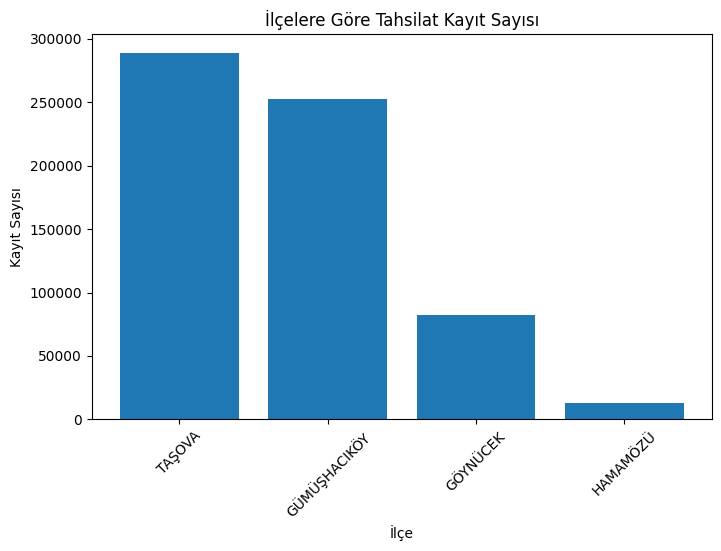

In [28]:
ilce_dagilim = df_tahsilat["İlçe"].value_counts()

display(ilce_dagilim.to_frame("Kayıt Sayısı"))

plt.figure(figsize=(8, 5))
plt.bar(ilce_dagilim.index, ilce_dagilim.values)

plt.title("İlçelere Göre Tahsilat Kayıt Sayısı")
plt.xlabel("İlçe")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=45)

plt.show()

Tahsilat kayıtları ilçelere göre farklı yoğunluk göstermektedir. Kayıt sayısının yüksek olduğu ilçeler (Taşova ve Gümüşhacıköy), müşteri sayısının ve ödeme işlem hacminin daha yüksek olduğu bölgeleri göstermektedir.

,Kayıt Sayısı
Şube,
AKTİFBANK,193135
ZİRAAT,117521
İŞBANK,87383
HALKBANK,60890
PTT,48760
Y.KREDİ,22528
GARANTİ,21221
AKBANK,20618
VAKIFLAR,14900


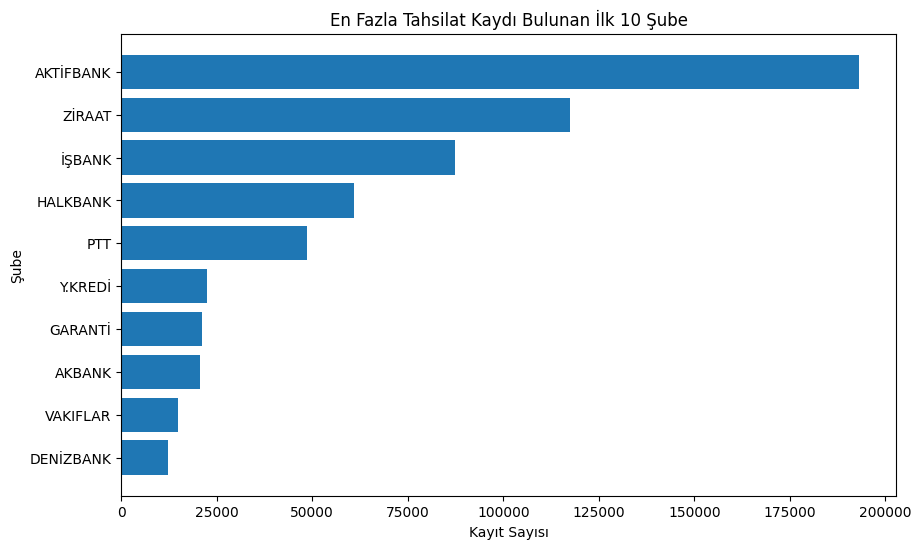

In [29]:
sube_dagilim = df_tahsilat["Şube"].value_counts().head(10)

display(sube_dagilim.to_frame("Kayıt Sayısı"))

plt.figure(figsize=(10, 6))
plt.barh(sube_dagilim.index, sube_dagilim.values)

plt.title("En Fazla Tahsilat Kaydı Bulunan İlk 10 Şube")
plt.xlabel("Kayıt Sayısı")
plt.ylabel("Şube")
plt.gca().invert_yaxis()

plt.show()

,Kayıt Sayısı
Nakit,523
Mahsuben,7542
Kredi Kartı,0
Banka,628933


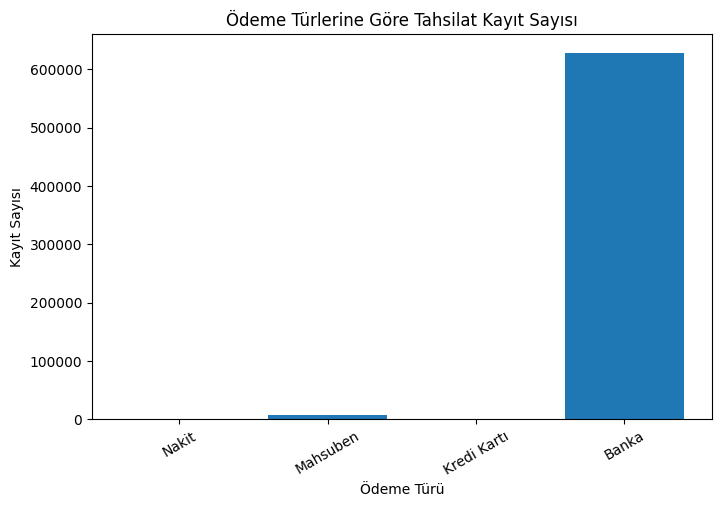

In [30]:
odeme_tipi = pd.Series({
    "Nakit": df_tahsilat["Nakit Tahsilat"].notna().sum(),
    "Mahsuben": df_tahsilat["Mahsuben Tahsilat"].notna().sum(),
    "Kredi Kartı": df_tahsilat["Kredi Kartı Tahsilatı"].notna().sum(),
    "Banka": df_tahsilat["Banka Tahsilatı"].notna().sum()
})

display(odeme_tipi.to_frame("Kayıt Sayısı"))

plt.figure(figsize=(8, 5))
plt.bar(odeme_tipi.index, odeme_tipi.values)

plt.title("Ödeme Türlerine Göre Tahsilat Kayıt Sayısı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Kayıt Sayısı")
plt.xticks(rotation=30)

plt.show()

In [31]:
df_tahsilat1 = pd.read_excel(
    file_path,
    sheet_name="Tahsilat 1"
)

df_tahsilat1.shape

(917632, 22)

In [32]:
print(df_tahsilat1.columns.tolist())

['Mali yıl/dönem', 'İl', 'İlçe', 'Söz.hsp.(bağımsız)', 'Hesap Sınıfı', 'Tahakkuk Tutar', 'Son Ödeme Tarihinden Önceki Tahsilat', 'Son Ödeme Tarihindeki Tahsilat', 'Son Ödeme (1)', 'Son Ödeme (2)', 'Son Ödeme (3)', 'Son Ödeme (4)', 'Son Ödeme (5)', 'Son Ödeme (6-10)', 'Son Ödeme (10-20)', 'Son Ödeme (20-30)', 'Son Ödeme (30-60)', 'Son Ödeme (60-90)', 'Son Ödeme (90-120)', 'Son Ödeme (120-150)', 'Son Ödeme (150-180)', 'Son Ödeme (180+)']


In [33]:
df_tahsilat1.head()

,Mali yıl/dönem,İl,İlçe,Söz.hsp.(bağımsız),Hesap Sınıfı,Tahakkuk Tutar,Son Ödeme Tarihinden Önceki Tahsilat,Son Ödeme Tarihindeki Tahsilat,Son Ödeme (1),Son Ödeme (2),...,Son Ödeme (5),Son Ödeme (6-10),Son Ödeme (10-20),Son Ödeme (20-30),Son Ödeme (30-60),Son Ödeme (60-90),Son Ödeme (90-120),Son Ödeme (120-150),Son Ödeme (150-180),Son Ödeme (180+)
0,OCK 2023,AMASYA,GÖYNÜCEK,9374624783,Mesken,5.03,0.03,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN
1,OCK 2023,AMASYA,GÖYNÜCEK,236184905,Mesken,26.46,0.06,26.40,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OCK 2023,AMASYA,GÖYNÜCEK,9657731015,Mesken,121.53,NaN,NaN,NaN,121.53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OCK 2023,AMASYA,GÖYNÜCEK,9554442880,Mesken,117.49,NaN,117.49,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OCK 2023,AMASYA,GÖYNÜCEK,6031642522,Mesken,170.30,170.30,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
gecikme = pd.Series({
    "Öncesinde": df_tahsilat1["Son Ödeme Tarihinden Önceki Tahsilat"].notna().sum(),
    "Ödeme Günü": df_tahsilat1["Son Ödeme Tarihindeki Tahsilat"].notna().sum(),
    "1 Gün": df_tahsilat1["Son Ödeme (1)"].notna().sum(),
    "2 Gün": df_tahsilat1["Son Ödeme (2)"].notna().sum(),
    "5 Gün": df_tahsilat1["Son Ödeme (5)"].notna().sum(),
    "6-10 Gün": df_tahsilat1["Son Ödeme (6-10)"].notna().sum(),
    "10-20 Gün": df_tahsilat1["Son Ödeme (10-20)"].notna().sum(),
    "20-30 Gün": df_tahsilat1["Son Ödeme (20-30)"].notna().sum(),
    "30-60 Gün": df_tahsilat1["Son Ödeme (30-60)"].notna().sum(),
    "60-90 Gün": df_tahsilat1["Son Ödeme (60-90)"].notna().sum(),
    "90-120 Gün": df_tahsilat1["Son Ödeme (90-120)"].notna().sum(),
    "120-150 Gün": df_tahsilat1["Son Ödeme (120-150)"].notna().sum(),
    "150-180 Gün": df_tahsilat1["Son Ödeme (150-180)"].notna().sum(),
    "180+ Gün": df_tahsilat1["Son Ödeme (180+)"].notna().sum()
})

display(gecikme.to_frame("Kayıt Sayısı"))

,Kayıt Sayısı
Öncesinde,623908
Ödeme Günü,328193
1 Gün,20902
2 Gün,21664
5 Gün,7323
6-10 Gün,45708
10-20 Gün,48281
20-30 Gün,29005
30-60 Gün,23030
60-90 Gün,7184


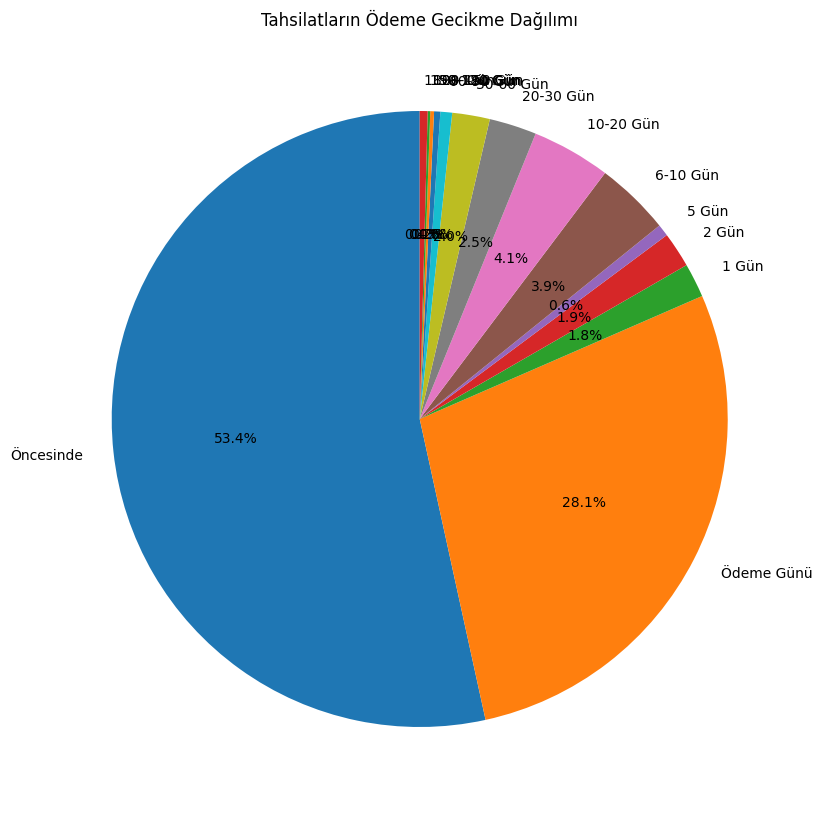

In [35]:
plt.figure(figsize=(10,10))

plt.pie(
    gecikme,
    labels=gecikme.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Tahsilatların Ödeme Gecikme Dağılımı")

plt.show()